In [242]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [238]:
def excess_function(x, *params):
    """Función de exceso genérica para sistema binario
    x: float, array
        Fracciones molares fase líquida compuesto 1
    params: float, array
        Vector de parámetros a utilizar
    """

    x1 = x
    x2 = 1 - x
    V_12 = 0
    for k, A_k in enumerate(params):
        V_12 = V_12 + A_k*(x1 - x2)**(k)
    V_12 = x1*x2*V_12
    
    return V_12

def MSE(y, y_hat):
    """Función error medio cuadrado
    y: float, array
        Datos reales
    y_hat: float, array
        Datos calculados
    """
    N = len(y)
    MSE = (y - y_hat)**2
    MSE = MSE.sum()/N
    MSE = np.sqrt(MSE)
    return MSE

In [239]:
data = pd.read_csv('data.csv')
data.columns = ['x', 've']

In [240]:
data.head()

,x,ve
0,1.000000,0.000000
1,0.898379,-0.334853
2,0.796656,-0.342866
3,0.687977,-0.291034
4,0.562247,-0.230091


In [297]:
parameters = []
errors = []
x_exp = 1 - data.x
y_exp = data.ve

n_params = [i for i in range(1,len(y_exp))]

for i in n_params:    
    params_i = curve_fit(
        excess_volume,
        x_exp,
        y_exp,
        p0=[np.ones(i)]
    )[0]
    parameters.append(params_i)
    
    y_hat = excess_function(x_exp, *params_i)
    
    error = MSE(y_hat, y_exp)
    errors.append(error)
    
    print(f'Ajuste con N parámetros:{i} | MSE: {error}')
    print(f'parameters:')
    pprint(list(parameters[i-1].round(5)))
    print('-'*79)
        

Ajuste con N parámetros:1 | MSE: 0.10877123525728755
parameters:
[-0.8039]
-------------------------------------------------------------------------------
Ajuste con N parámetros:2 | MSE: 0.04851843790990221
parameters:
[-0.98233, 1.47236]
-------------------------------------------------------------------------------
Ajuste con N parámetros:3 | MSE: 0.024310635715715085
parameters:
[-0.75714, 1.59241, -1.43194]
-------------------------------------------------------------------------------
Ajuste con N parámetros:4 | MSE: 0.013401776472824456
parameters:
[-0.70219, 1.05419, -1.67653, 1.54784]
-------------------------------------------------------------------------------
Ajuste con N parámetros:5 | MSE: 0.0052674834590214405
parameters:
[-0.78003, 1.00113, -0.4063, 1.71806, -2.26611]
-------------------------------------------------------------------------------
Ajuste con N parámetros:6 | MSE: 0.0038261079820135903
parameters:
[-0.79133, 1.13644, -0.29341, 0.65842, -2.4454, 1.45331]


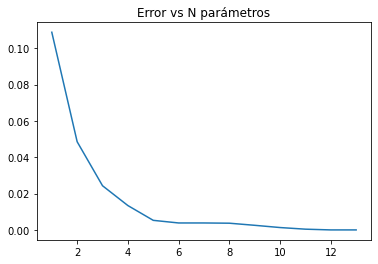

In [298]:
plt.plot(n_params, errors)
plt.title('Error vs N parámetros')
plt.show()

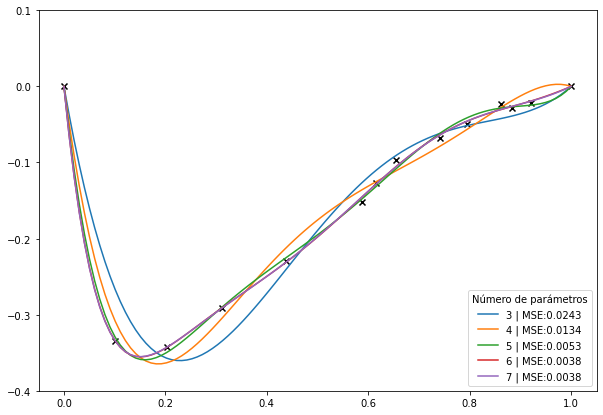

In [299]:
plt.figure(figsize=(10,7))
plt.scatter(x_exp, y_exp, marker='x', color='black')
x = np.linspace(x_exp.min(), x_exp.max(), 100)

for i in range(2, 7):
    params = parameters[i]
    y_hat = excess_function(x, *params)
    plt.plot(
        x,
        y_hat, 
        label=f'{i+1} | MSE:{errors[i]:.4f}'
    )

plt.legend(title='Número de parámetros')
plt.ylim(-0.4,0.1)
plt.show()

# Ejercicio 3: Ajuste de datos EVL
- compuesto 1: dietilcetona
- compuesto 2: n-hexano
- temperatura: 65°C

## Ajuste de datos con Margules

### Definición de funciones

Se definen funciones para:
- Cálculos de $\log(\gamma)$ según Margules
- Cálculos de presión de vapor y rocío según parámetros de Margules
- Función objetivo a minimizar

In [300]:
def ln_gamma(x, A, B):
    """Función logaritmo de gamma
    x : Fracción molar compuesto 1
    A : Parámetro A12
    B : Parámetro A21
    """
    return (1-x)**2*(A + 2*(B - A)*x)


def dln_gamma(x, A, B):
    """Función derivada logaritmo de gamma con respecto a x1
    x : Fracción molar compuesto 1
    A : Parámetro A12
    B : Parámetro A21
    """
    return 2*(B - A)
    

def bub_P(x, A, B, P):
    """Presión de burbuja
    x : Fracción molar compuesto 1 en fase líquida
    A : Parámetro A12
    B : Parámetro A21
    """
    P1 = P[0]
    P2 = P[1]
    
    gamma_1 = np.exp(ln_gamma(x, A, B))
    gamma_2 = np.exp(ln_gamma(1-x, B, A))
    P = gamma_1*x*P1 + gamma_2*(1-x)*P2
    return P

def dew_P(XY, A, B, P):
    """Presión de rocío
    XY : Vector [x1, y1],
         x1 : Fracción molar compuesto 1 en fase líquida
         y1 : Fracción molar compuesto 1 en fase vapor    
    A : Parámetro A12
    B : Parámetro A21
    """
    x = XY[0]
    y = XY[1]
    
    P1 = P[0]
    P2 = P[1]

    gamma_1 = np.exp(ln_gamma(x, A, B))
    gamma_2 = np.exp(ln_gamma(1-x, B, A))
    
    P = y/(gamma_1*P1) + (1-y)/(gamma_2*P2)
    P = 1/P

    return P
  

def obj_func(XYP, A, B, P):
    """Función objetivo a minimizar
    XYP : Vector [x1, y1, P],
         x1 : Fracción molar compuesto 1 en fase líquida
         y1 : Fracción molar compuesto 1 en fase vapor
         P  : Presión
    A : Parámetro A12
    B : Parámetro A21
    """
    bP = bub_P(XYP[0], A, B, P)
    dP = dew_P(XYP, A, B, P)
    Pobj = XYP[2]
    
    bP = np.mean((bP - Pobj)**2)
    dP = np.mean((dP - Pobj)**2)
    
    obj = (bP + dP)/2
    
    return obj

### Datos experimentales

In [301]:
# Presiones experimentales
P = np.array([
    90.15, 91.78, 88.01, 81.67, 78.89,
    76.82, 73.39, 66.45, 62.95, 57.70,
    50.16, 45.70, 29.00
])


# Valores de x experimentales
x1 = np.array([
    0.000, 0.063, 0.248, 0.372, 0.443,
    0.508, 0.561, 0.640, 0.702, 0.763, 
    0.834, 0.874, 1.000
    
])

# Valores de y experimentales

# Datos experimentales como matriz para compatibilidad con las funciones
XYP = [x1,y1,P]

y1 = np.array([
    0.000, 0.049, 0.131, 0.182, 0.215,
    0.248, 0.268, 0.316, 0.368, 0.412,
    0.490, 0.570, 1.000
])


# Presiones de saturación de compuesto 1 y 2
Ps = [
    P[-1],
    P[0]
]

# Datos experimentales como matriz para compatibilidad con las funciones
XYP = [x1,y1,P]


In [302]:
# Definir como función lambda para fijar el valor de Ps
# al momento de ajustar (de lo contrario se considerarían como un parámetro)
f = lambda x, A, B: obj_func(XYP, A, B, Ps)

In [303]:
# Objetivo: Función objetivo igual a cero 
# (lo ideal sería minimizar en realidad)
obj = np.zeros_like(y1)

# Ajustar valores
A, B = curve_fit(f, XYP, obj)[0]
print(A, B)

1.143848805786318 0.6889148536868253


/usr/lib/python3.9/site-packages/scipy/optimize/minpack.py:833: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


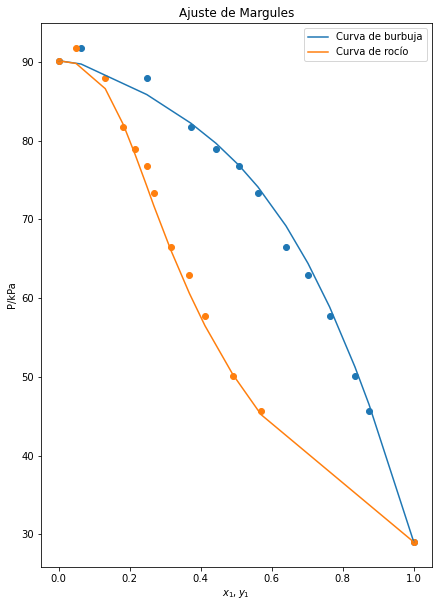

In [304]:
plt.figure(figsize=(7,10))

# Curva de burbuja calculada
plt.scatter(x1, P)
plt.scatter(y1, P)

# Curva de burbuja calculada
plt.plot(x1, bub_P(x1, A, B, Ps), label='Curva de burbuja')

# Curva de rocío calculada
XY = [x1,y1]
plt.plot(y1, dew_P(XY, A, B, Ps), label='Curva de rocío')


# Formato de gráfico

plt.title('Ajuste de Margules')

plt.ylabel('P/kPa')
plt.xlabel(r'$x_1, y_1$')
plt.legend()

In [356]:
# Función objetivo valuada
f(XYP, A, B)
print(A,B)

1.143848805786318 0.6889148536868253


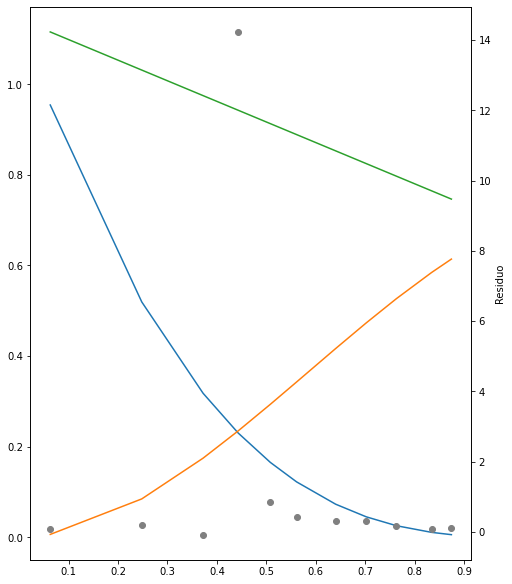

In [362]:
# Obviar los valores en los que x1=0 y x2=0
x1_exp = x1[1:-1]
y1_exp = y1[1:-1]
P_exp = P[1:-1]

P1 = P[-1]
P2 = P[0]

fig, ax1 = plt.subplots(figsize=(7,8), 
                       constrained_layout=True)

ax2 = ax1.twinx()


lngamma1_exp = np.log(y1_exp*P_exp/(x1_exp*P1))
lngamma2_exp = np.log((1-y1_exp)*P_exp/((1-x1_exp)*P2))

ln_gamma1 = ln_gamma(x1_exp, A, B)
ln_gamma2 = ln_gamma(1-x1_exp, B, A)

GEx1x2 = B*x1_exp + A*(1-x1_exp)

#ax1.scatter(x1_exp, lngamma1_exp, marker='x', color='red')
ax1.plot(x1_exp, ln_gamma1)

#ax1.scatter(x1_exp, lngamma2_exp, marker='x', color='blue')
ax1.plot(x1_exp, ln_gamma2)

ax1.plot(x1_exp, GEx1x2)


# Cálculo y gráfico de residuo
delta = (
    (ln_gamma1-ln_gamma2) - (lngamma1_exp - lngamma2_exp)
    )/(
    ln_gamma1-ln_gamma2
)

ax2.scatter(x1_exp, delta * (GEx1x2), color='gray')
ax2.set_ylabel('Residuo')

plt.show()